<a href="https://colab.research.google.com/github/Darkcode-Git/Ecosistema-Python-para-An-lisis-de-Datos/blob/main/Soluci%C3%B3n_de_un_problema_bancario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ejecutando simulaciones...

--- RESULTADOS DEL ANÁLISIS ---

1. Tiempo promedio de atención (servicio) por cajero:
                      Modelo   Cajero  Servicio
Modelo A (2 Retiros, 1 Pago)   Pago_0  5.168936
Modelo A (2 Retiros, 1 Pago) Retiro_0  2.352664
Modelo A (2 Retiros, 1 Pago) Retiro_1  2.200360
Modelo B (1 Retiro, 2 Pagos)   Pago_0  5.162404
Modelo B (1 Retiro, 2 Pagos)   Pago_1  4.897668
Modelo B (1 Retiro, 2 Pagos) Retiro_0  2.312567

2. Promedio de usuarios de cada tipo (por día):
                      Modelo Accion      Tipo  Promedio por día
Modelo A (2 Retiros, 1 Pago)   Pago     Lento         17.383750
Modelo A (2 Retiros, 1 Pago)   Pago Muy lento         23.111250
Modelo A (2 Retiros, 1 Pago)   Pago    Normal         11.618750
Modelo A (2 Retiros, 1 Pago)   Pago    Rápido          5.828321
Modelo A (2 Retiros, 1 Pago) Retiro     Lento         23.661250
Modelo A (2 Retiros, 1 Pago) Retiro Muy lento         27.873750
Modelo A (2 Retiros, 1 Pago) Retiro    Normal       

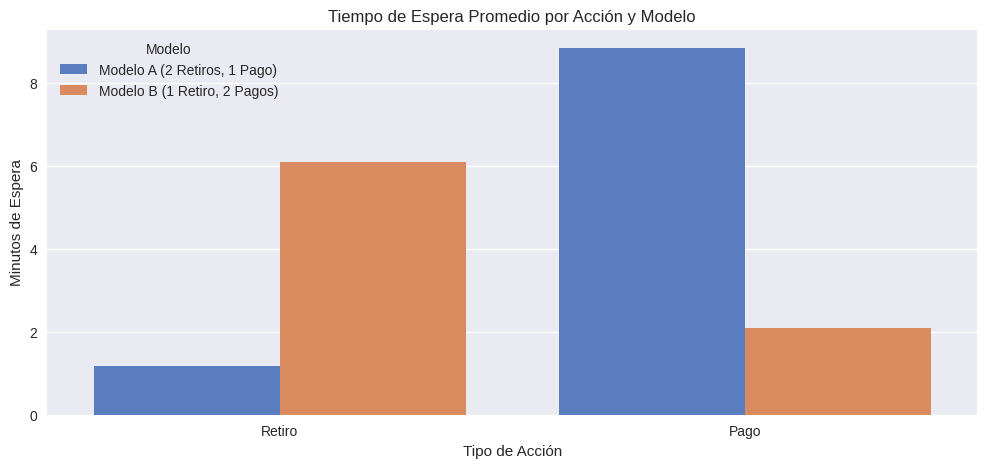

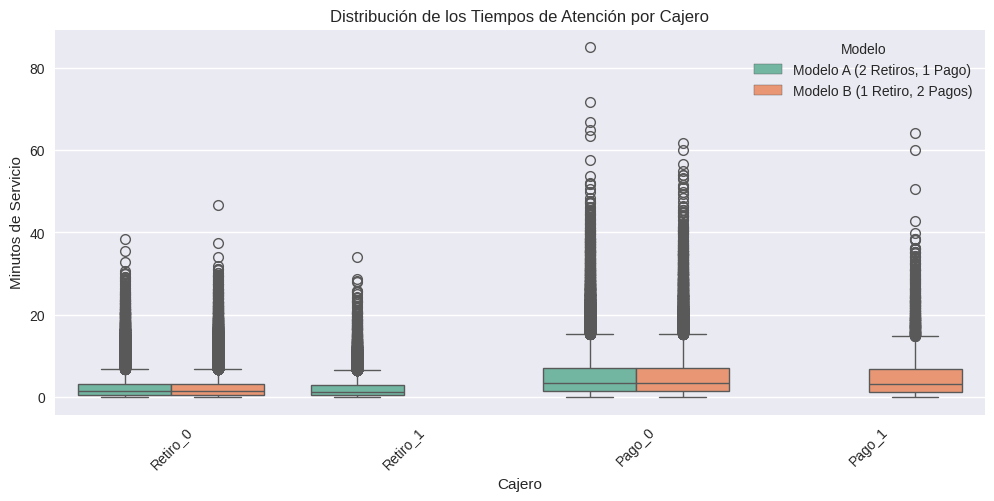

In [ ]:
!pip install simpy

import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# ==========================================
# 1. DEFINICIÓN DE PARÁMETROS Y TABLAS
# ==========================================
TIEMPO_SIMULACION = 8 * 60  # 8 horas en minutos (480 min)
REPLICAS = 800


# Probabilidades principales
PROB_RETIRO = 0.70
PROB_PAGO = 0.30

# Tabla 1 y 2 combinadas: {Acción: {Tipo: (Probabilidad, Media Servicio, Media Llegada)}}
datos_usuarios = {
    'Retiro': {
        'Rápido': (0.23, 1, 1),
        'Normal': (0.40, 2, 2),
        'Lento': (0.17, 3, 3),
        'Muy lento': (0.20, 4, 3)
    },
    'Pago': {
        'Rápido': (0.10, 3, 1),
        'Normal': (0.20, 3, 2),
        'Lento': (0.30, 5, 3),
        'Muy lento': (0.40, 7, 4)
    }
}

# ==========================================
# 2. LÓGICA DE LA SIMULACIÓN
# ==========================================
class BancoSimulacion:
    def __init__(self, env, num_retiros, num_pagos):
        self.env = env
        # Crear cajeros independientes (M/M/1)
        self.cajeros_retiro = [simpy.Resource(env, capacity=1) for _ in range(num_retiros)]
        self.cajeros_pago = [simpy.Resource(env, capacity=1) for _ in range(num_pagos)]

        # Recolección de datos
        self.registro_usuarios = []
        self.tiempos_cajeros = {f'Retiro_{i}': [] for i in range(num_retiros)}
        self.tiempos_cajeros.update({f'Pago_{i}': [] for i in range(num_pagos)})

    def atencion(self, usuario, accion, tipo_usuario, tiempo_servicio):
        llegada = self.env.now

        # Seleccionar el cajero con la fila más corta (M/M/1 independientes)
        if accion == 'Retiro':
            cajero_elegido = min(range(len(self.cajeros_retiro)), key=lambda i: len(self.cajeros_retiro[i].queue))
            cajero = self.cajeros_retiro[cajero_elegido]
            nombre_cajero = f'Retiro_{cajero_elegido}'
        else:
            cajero_elegido = min(range(len(self.cajeros_pago)), key=lambda i: len(self.cajeros_pago[i].queue))
            cajero = self.cajeros_pago[cajero_elegido]
            nombre_cajero = f'Pago_{cajero_elegido}'

        # Proceso de hacer la fila y ser atendido
        with cajero.request() as req:
            yield req
            espera = self.env.now - llegada

            # Tiempo de atención (servicio)
            t_servicio_real = np.random.exponential(tiempo_servicio)
            yield self.env.timeout(t_servicio_real)

            # Guardar estadísticas
            self.registro_usuarios.append({
                'Accion': accion,
                'Tipo': tipo_usuario,
                'Espera': espera,
                'Servicio': t_servicio_real,
                'Cajero': nombre_cajero
            })
            self.tiempos_cajeros[nombre_cajero].append(t_servicio_real)

def generador_usuarios(env, banco):
    usuario_id = 0
    while True:
        # Determinar acción (70% Retiros, 30% Pagos)
        accion = np.random.choice(['Retiro', 'Pago'], p=[PROB_RETIRO, PROB_PAGO])

        # Determinar tipo de usuario según la acción
        tipos = list(datos_usuarios[accion].keys())
        probs = [datos_usuarios[accion][t][0] for t in tipos]
        tipo_usuario = np.random.choice(tipos, p=probs)

        # Obtener tiempos medios de las tablas
        media_servicio = datos_usuarios[accion][tipo_usuario][1]
        media_llegada = datos_usuarios[accion][tipo_usuario][2]

        # Generar próximo tiempo de llegada exponencial
        t_llegada = np.random.exponential(media_llegada)
        yield env.timeout(t_llegada)

        # Iniciar proceso de atención
        usuario_id += 1
        env.process(banco.atencion(usuario_id, accion, tipo_usuario, media_servicio))

def ejecutar_modelo(num_retiros, num_pagos, nombre_modelo):
    resultados = []
    for rep in range(REPLICAS):
        env = simpy.Environment()
        banco = BancoSimulacion(env, num_retiros, num_pagos)
        env.process(generador_usuarios(env, banco))
        env.run(until=TIEMPO_SIMULACION)

        # Recopilar df de la réplica
        df = pd.DataFrame(banco.registro_usuarios)
        df['Replica'] = rep + 1
        df['Modelo'] = nombre_modelo
        resultados.append(df)

    return pd.concat(resultados, ignore_index=True)

# ==========================================
# 3. EJECUCIÓN DE LOS ESCENARIOS
# ==========================================
print("Ejecutando simulaciones...")
# Modelo A: 2 Retiros, 1 Pago
df_modelo_a = ejecutar_modelo(2, 1, "Modelo A (2 Retiros, 1 Pago)")

# Modelo B: 1 Retiro, 2 Pagos
df_modelo_b = ejecutar_modelo(1, 2, "Modelo B (1 Retiro, 2 Pagos)")

df_total = pd.concat([df_modelo_a, df_modelo_b], ignore_index=True)

# ==========================================
# 4. CÁLCULO DE ESTADÍSTICAS Y SOLUCIONES
# ==========================================

print("\n--- RESULTADOS DEL ANÁLISIS ---")

# 1. Cajero con menor y mayor tiempo promedio de atención
atencion_cajeros = df_total.groupby(['Modelo', 'Cajero'])['Servicio'].mean().reset_index()
print("\n1. Tiempo promedio de atención (servicio) por cajero:")
print(atencion_cajeros.to_string(index=False))

# 2. Promedio de usuarios de cada tipo en la totalidad de cajeros
usuarios_tipo_total = df_total.groupby(['Modelo', 'Accion', 'Tipo', 'Replica']).size().reset_index(name='Cantidad')
promedio_usuarios_tipo = usuarios_tipo_total.groupby(['Modelo', 'Accion', 'Tipo'])['Cantidad'].mean().reset_index(name='Promedio por día')
print("\n2. Promedio de usuarios de cada tipo (por día):")
print(promedio_usuarios_tipo.to_string(index=False))

# 3. Total de usuarios de cada tipo por réplica y modelo con menor cantidad
print("\n3. Resumen de cantidades de usuarios (promedios diarios por modelo):")
total_por_modelo = usuarios_tipo_total.groupby(['Modelo', 'Replica'])['Cantidad'].sum().reset_index()
media_total_modelo = total_por_modelo.groupby('Modelo')['Cantidad'].mean()
print(media_total_modelo)
print("-> El modelo con menor cantidad de usuarios variará ligeramente por la aletoriedad, pero tienden a ser iguales porque la llegada es independiente del cajero.")

# 4. & 5. Tiempos promedio de espera para decidir configuración y necesidad de nuevo cajero
esperas = df_total.groupby(['Modelo', 'Accion'])['Espera'].mean().reset_index()
print("\n4 y 5. Tiempos promedio de ESPERA en fila (minutos):")
print(esperas.to_string(index=False))

# ==========================================
# 5. GRÁFICOS
# ==========================================
plt.figure(figsize=(12, 5))
sns.barplot(x='Accion', y='Espera', hue='Modelo', data=df_total, errorbar=None, palette="muted")
plt.title('Tiempo de Espera Promedio por Acción y Modelo')
plt.ylabel('Minutos de Espera')
plt.xlabel('Tipo de Acción')
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x='Cajero', y='Servicio', hue='Modelo', data=df_total, palette="Set2")
plt.title('Distribución de los Tiempos de Atención por Cajero')
plt.ylabel('Minutos de Servicio')
plt.xlabel('Cajero')
plt.xticks(rotation=45)
plt.show()